# Information Presentation & Data Visualisation

## 06 Lab Exercise sheet: Maps and scientific visualisations

This lab is designed to provide hands-on practice with cartographic and scientific visualisations.

## NSS Survey

We only have until 28 February to complete the NSS survey and get the chance of winning one of our great prizes. To complete it please go here: https://www.thestudentsurvey.com/ 

## Task 1: London to Boston using different world map projections
Compare the visual representation of the distance between London ('latitude': 51.5074, 'longitude': -0.1278) and Boston ('latitude': 42.3601, 'longitude': -71.0589) by drawing a line connecting the two cities across different world map projections and observe how the map projections affect the appearance of the distance.

In [115]:
import pandas as pd
import altair as alt
from vega_datasets import data

# Coordinates
boston = {'city': 'Boston', 'lat': 42.3601, 'lon': -71.0589}
london = {'city': 'London', 'lat': 51.5074, 'lon': -0.1278}

# City points
points = pd.DataFrame([boston, london])

# Line data (Boston -> London)
line_data = pd.DataFrame([
    {'lon': boston['lon'], 'lat': boston['lat'], 'order': 0},
    {'lon': london['lon'], 'lat': london['lat'], 'order': 1}
])

# Load world map
world = alt.topo_feature(data.world_110m.url, "countries")

# Define projections to compare
projections = [
    {'type': 'naturalEarth1', 'name': 'Natural Earth'},
    {'type': 'mercator', 'name': 'Mercator'},
    {'type': 'equirectangular', 'name': 'Equirectangular'},
    {'type': 'orthographic', 'name': 'Orthographic'},
    {'type': 'azimuthalEquidistant', 'name': 'Azimuthal Equidistant'},
    {'type': 'stereographic', 'name': 'Stereographic'}
]

# Create charts for each projection
charts = []

for proj in projections:
    # Base world map
    base_map = alt.Chart(world).mark_geoshape(
        fill='lightgray',
        stroke='white',
        strokeWidth=0.5
    ).project(
        type=proj['type']
    ).properties(
        title=f"{proj['name']} Projection",
        width=350,
        height=250
    )
    
    # Line connecting cities
    line_chart = alt.Chart(line_data).mark_line(
        color='red', 
        strokeWidth=2
    ).encode(
        longitude='lon:Q',
        latitude='lat:Q',
        order='order:O'
    )
    
    # City points
    points_chart = alt.Chart(points).mark_point(
        size=100, 
        color='blue',
        filled=True
    ).encode(
        longitude='lon:Q',
        latitude='lat:Q',
        tooltip=['city:N']
    )
    
    # City labels
    labels_chart = alt.Chart(points).mark_text(
        align='left', 
        dx=7, 
        dy=-7, 
        fontSize=11,
        fontWeight='bold',
        color='darkblue'
    ).encode(
        longitude='lon:Q',
        latitude='lat:Q',
        text='city:N'
    )
    
    # Combine layers
    map_chart = base_map + line_chart + points_chart + labels_chart
    charts.append(map_chart)

# Arrange charts in a 3x2 grid
final_chart = alt.vconcat(
    alt.hconcat(charts[0], charts[1]),
    alt.hconcat(charts[2], charts[3]),
    alt.hconcat(charts[4], charts[5])
).properties(
    title=alt.TitleParams(
        text='London to Boston Distance Across Different Map Projections',
        fontSize=16,
        anchor='middle'
    )
).configure_view(
    strokeWidth=0
)

final_chart

alt.VConcatChart(...)

## Task 2: Combining multiple data sources on a map
Combine the `world_110m` with country-specific life expectancy values from the `Gapminder` dataset and visualize the results on an interactive map. You will clean the data, match country names by id using the `world-110m-country-codes` table, and create an interactive map showing the country name, abbreviation and life expectancy across different countries in 2005.

In [119]:
import pandas as pd
import altair as alt
from vega_datasets import data

# Load world map and country codes
world_map = alt.topo_feature(data.world_110m.url, 'countries')
country_codes = pd.read_json('world-110m-country-codes.json')
country_codes = country_codes[['id', 'name', 'code']]

# Load Gapminder data
df = data.gapminder()
df['country'] = df['country'].str.strip().str.upper()
country_codes['name'] = country_codes['name'].str.strip().str.upper()

# Filter life expectancy for 2005
df_life_expectancy = df[df['year'] == 2005][['country','life_expect']]

# Merge Gapminder data with country codes
country_codes = country_codes.merge(
    df_life_expectancy,
    left_on='name',
    right_on='country',
    how='left'
)

# Create choropleth map
chart = alt.Chart(world_map).mark_geoshape(
    fill='teal',
    stroke='gray'
).encode(
    tooltip=['name:N', 'code:N', 'life_expect:Q']
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(country_codes, 'id', ['name','code','life_expect'])
).properties(
    width=800,
    height=400,
    title='World Life Expectancy (2005)'
)

chart.show()

alt.Chart(...)

## Task 3: Create an interactive choropleth map of US unemployment rates with a categorical colour palette
Create an interactive choropleth map to visualise unemployment rates across different counties in the United States. The map should categorise counties based on their unemployment rate, with each category represented using a custom colour palette based on colour names.

In [121]:
import altair as alt
import pandas as pd
from vega_datasets import data

# Load unemployment data (tab-separated)
unemp = pd.read_csv(data.unemployment.url, sep='\t')

# Check data
print(unemp.head())  # should show columns 'id' and 'rate'

# Create categorical column for unemployment rates
unemp['rate_cat'] = pd.cut(
    unemp['rate'],
    bins=[0, 0.03, 0.05, 0.07, 0.09, 1],  # thresholds as fractions
    labels=['0-3%', '3-5%', '5-7%', '7-9%', '9%+'],
    include_lowest=True
)

# Define a custom categorical color scale
color_scale = alt.Scale(
    domain=['0-3%', '3-5%', '5-7%', '7-9%', '9%+'],
    range=['#2ca02c', '#98df8a', '#ffcc00', '#ff7f0e', '#d62728']
)

# Load US counties TopoJSON
usa = data.us_10m.url

# Create the choropleth map
unemployment_map = alt.Chart(alt.topo_feature(usa, 'counties')).mark_geoshape(
    stroke='#aaa',
    strokeWidth=0.25
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(unemp, key='id', fields=['rate', 'rate_cat'])
).encode(
    color=alt.Color('rate_cat:N', scale=color_scale, legend=alt.Legend(title='Unemployment Rate')),
    tooltip=[
        alt.Tooltip('rate_cat:N', title='Category'),
        alt.Tooltip('rate:Q', title='Rate (%)', format='.1f')
    ]
).project(
    type='albersUsa'
).properties(
    width=900,
    height=500,
    title={
        'text': 'US County Unemployment Rates by Category',
        'fontSize': 18,
        'anchor': 'middle'
    }
).configure_view(
    strokeWidth=0
)

# Display map
unemployment_map.show()

     id   rate
0  1001  0.097
1  1003  0.091
2  1005  0.134
3  1007  0.121
4  1009  0.099


alt.Chart(...)

## Taks 4: Comparative statistical visualisation
1. Use box plots and violin plots to compare the distributions of petal length across species in iris dataset.
2. Apply statistical annotations (e.g., significance levels from t-tests or ANOVA).
3. Interpret the visual output to describe key differences.

/var/folders/r0/63whb4hs3bsdqdrfkkql5hb40000gn/T/ipykernel_44947/818016442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length', data=iris, palette='Set2')
/var/folders/r0/63whb4hs3bsdqdrfkkql5hb40000gn/T/ipykernel_44947/818016442.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y='petal_length', data=iris, palette='Set2', inner='quartile')


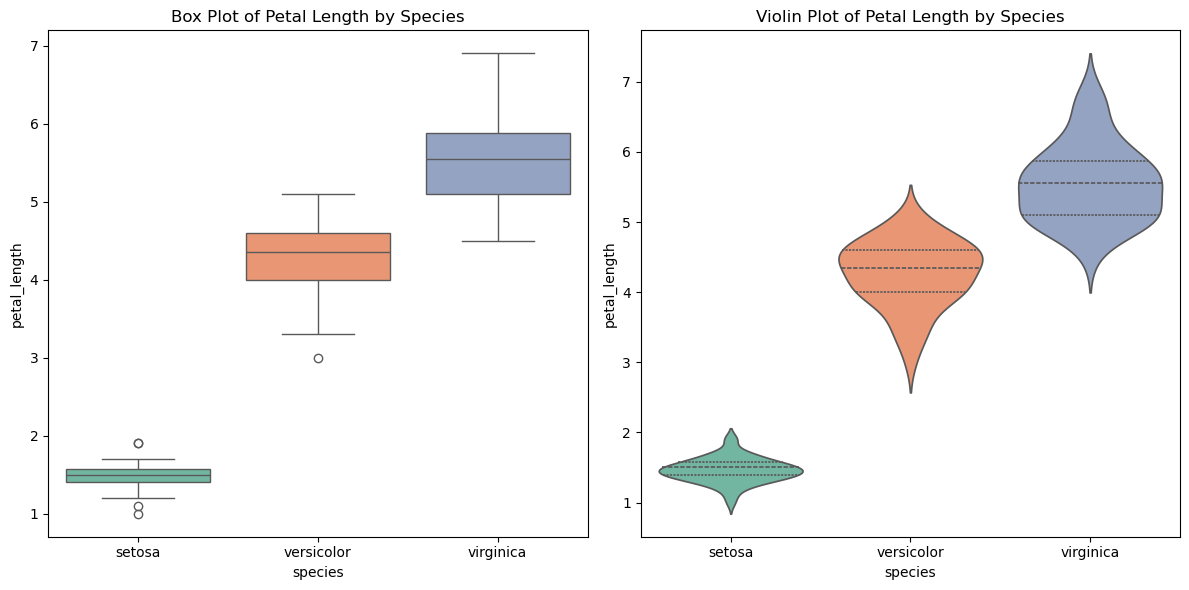

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Load Iris dataset
iris = sns.load_dataset('iris')
plt.figure(figsize=(12, 6))

# Box plot
plt.subplot(1, 2, 1)
sns.boxplot(x='species', y='petal_length', data=iris, palette='Set2')
plt.title('Box Plot of Petal Length by Species')

# Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(x='species', y='petal_length', data=iris, palette='Set2', inner='quartile')
plt.title('Violin Plot of Petal Length by Species')

plt.tight_layout()
plt.show()


In [125]:
# ANOVA across all three species
anova = stats.f_oneway(
    iris[iris['species'] == 'setosa']['petal_length'],
    iris[iris['species'] == 'versicolor']['petal_length'],
    iris[iris['species'] == 'virginica']['petal_length']
)
print("ANOVA F-statistic:", anova.statistic, "p-value:", anova.pvalue)

# Pairwise t-tests
from itertools import combinations

species = iris['species'].unique()
pairs = list(combinations(species, 2))

print("\nPairwise t-tests (Bonferroni corrected):")
for s1, s2 in pairs:
    t_stat, p_val = stats.ttest_ind(
        iris[iris['species'] == s1]['petal_length'],
        iris[iris['species'] == s2]['petal_length']
    )
    p_val_corrected = min(p_val * len(pairs), 1.0)  # Bonferroni correction
    print(f"{s1} vs {s2}: t={t_stat:.2f}, p={p_val_corrected:.3f}")


ANOVA F-statistic: 1180.161182252981 p-value: 2.8567766109615584e-91

Pairwise t-tests (Bonferroni corrected):
setosa vs versicolor: t=-39.49, p=0.000
setosa vs virginica: t=-49.99, p=0.000
versicolor vs virginica: t=-12.60, p=0.000


## Task 5: Wrangling Geographic Data

The examples above all draw from the vega-datasets collection, including geometric (TopoJSON) and tabular (airports, unemployment rates) data. A common challenge to getting starting with geographic visualization is collecting the necessary data for your task. A number of data providers abound, including services such as the [United States Geological Survey](https://www.usgs.gov/products/data/all-data) and [U.S. Census Bureau](https://www.census.gov/data/datasets.html).

In many cases you may have existing data with a geographic component, but require additional measures or geometry. To help you get started, here is one workflow:

1. Visit [Natural Earth Data](http://www.naturalearthdata.com/downloads/) and browse to select data for regions and resolutions of interest. Download the corresponding zip file(s).
2. Go to [MapShaper](https://mapshaper.org/) and drop your downloaded zip file onto the page. Revise the data as desired, and then "Export" generated TopoJSON or GeoJSON files.
3. Load the exported data from MapShaper for use with Altair!


### Worksheets should be submitted on Canvas by the Monday after the lab at 23:59.